In [2]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import display, clear_output
from astropy.table import Table, vstack
from astropy.io import fits
import random
import os

In [2]:
# Load the FITS file
SGA = Table.read('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/152by152_sga2020.fits')

# Initialize 'T_TYPE' and 'Main_Type' columns
SGA.add_column(np.nan, name='T_TYPE')
SGA.add_column(30, name='Main_Type')

# Define mapping for T_TYPE based on 'Morphology'
morphology_to_type = {
    'E': -5,
    'S0': -2,
    'S0-a': 0,
    'Sa': 1,
    'Sab': 2,
    'Sb': 3,
    'Sbc': 4,
    'Sc': 5,
    'Scd': 6,
    'Sd': 7,
    'Sm': 9,
    'Irr': 10,
    'dIrr': 10,
    'I': 10,
    'dSph': 11
}

# Assign values to 'T_TYPE'
for morph, t_type in morphology_to_type.items():
    SGA['T_TYPE'][SGA['Morphology'] == morph] = t_type

# Assign 'Main_Type' based on 'T_TYPE'
SGA['Main_Type'][SGA['T_TYPE'] == -5] = 20  # Ellipticals
SGA['Main_Type'][(SGA['T_TYPE'] == -2) | (SGA['T_TYPE'] == 0)] = 0  # Lenticulars
SGA['Main_Type'][(SGA['T_TYPE'] >= 1) & (SGA['T_TYPE'] <= 7)] = 10  # Spirals
#SGA['Main_Type'][(SGA['T_TYPE'] == 9) | (SGA['T_TYPE'] == 10)] = -5  # Irregulars
SGA['Main_Type'][SGA['T_TYPE'] == 10] = -5 # Irregulars

# Remove rows with undefined 'Main_Type'
SGA = SGA[SGA['Main_Type'] != 30]

# Split the dataset into samples
sample_elliptical = SGA[SGA['Main_Type'] == 20]
sample_lenticular = SGA[SGA['Main_Type'] == 0]
sample_spiral = SGA[SGA['Main_Type'] == 10]
sample_irregular = SGA[SGA['Main_Type'] == -5]

In [62]:
sample_irregular

SGA_ID,RA,DEC,G_MAG_SB26,Z_MAG_SB26,R_MAG_SB26,Morphology,Path,T_TYPE,Main_Type
int64,float64,float64,float32,float32,float32,bytes21,bytes255,float64,int64
547,211.97785473592506,54.70342842542335,16.883043,16.207956,16.284546,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/211/SGA2020-000547.fits,10.0,-5
932,183.86376966957695,10.512361301360915,17.57759,17.096212,17.300507,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/183/SGA2020-000932.fits,10.0,-5
1044,130.4364399585564,57.37921651285226,16.651321,16.113508,16.173828,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/130/SGA2020-001044.fits,10.0,-5
1297,25.628726752204933,-0.8194142322789576,15.297923,14.5408535,14.861985,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/025/SGA2020-001297.fits,10.0,-5
1657,232.68485506633013,47.31904255282356,16.547918,17.445566,16.103655,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/232/SGA2020-001657.fits,10.0,-5
1787,235.27675269905802,4.7529951548194065,17.392366,16.696262,16.959574,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/235/SGA2020-001787.fits,10.0,-5
2056,193.69299749312026,15.591724570040274,16.56931,16.071106,16.263586,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/193/SGA2020-002056.fits,10.0,-5
2274,138.21551376367623,31.681078799311003,17.014498,16.802586,16.860426,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/138/SGA2020-002274.fits,10.0,-5
2336,174.95278545214944,46.619713162396074,16.355526,16.147505,16.02667,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/174/SGA2020-002336.fits,10.0,-5


In [63]:
# Lists to keep track of correct and incorrect images
correct_list = []
incorrect_list = []
inspected_ids = set()  # Initialize inspected ids set

# Read existing IDs from the .txt file and add them to the set
try:
    with open('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/inspected_ids_irregular.txt', 'r') as f:
        for line in f:
            # Add each ID to the set (assuming IDs are integers or strings)
            inspected_ids.add(line.strip())
except FileNotFoundError:
    # Handle the case where the file does not exist yet
    pass

In [64]:
# Function to load image data from FITS file
def load_image(path):
    try:
        with fits.open(path) as fits_file:
            image = fits_file[0].data
            if image.shape[0] == 3:
                image = np.transpose(image, (1, 2, 0))
                
                g_image = np.array(image[:,:,0])
                r_image = np.array(image[:,:,1])
                z_image = np.array(image[:,:,2])
                
            return image, g_image, r_image, z_image
        
    except Exception as e:
        print(f"Error loading image: {e}")
        return None

In [65]:
# Display the image and morphology
def display_image(index, sample_type):
    print(f"Displaying image for index: {index} and sample type: {sample_type}")
    
    if sample_type == 'Elliptical':
        sample = sample_elliptical
    elif sample_type == 'Lenticular':
        sample = sample_lenticular
    elif sample_type == 'Spiral':
        sample = sample_spiral
    elif sample_type == 'Irregular':
        sample = sample_irregular
    else:
        print("Invalid sample type.")
        return

    if index >= len(sample):
        print("Index out of bounds.")
        return

    path = sample[index]['Path']
    morphology = sample[index]['Morphology']
    print(f"Loading image from {path} with morphology: {morphology}.")

    image_data = image, g_image, r_image, z_image = load_image(path)
    if image_data is None:
        print("Image data is None.")
        return

    plt.figure(figsize=(13, 8), facecolor = 'black')

    # Create a 2x2 grid of subplots
    ax1 = plt.subplot(2, 2, 1)
    ax1.imshow(image, origin='lower', cmap='plasma')
    ax1.set_title('Full Image')
    ax1.axis('off')

    ax2 = plt.subplot(2, 2, 2)
    ax2.imshow(g_image, origin='lower', cmap='Greens')
    ax2.set_title('g Band')
    ax2.axis('off')

    ax3 = plt.subplot(2, 2, 3)
    ax3.imshow(r_image, origin='lower', cmap='Reds')
    ax3.set_title('r Band')
    ax3.axis('off')

    ax4 = plt.subplot(2, 2, 4)
    ax4.imshow(z_image, origin='lower', cmap='Purples')
    ax4.set_title('z Band')
    ax4.axis('off')

    plt.tight_layout()
    plt.show()

In [66]:
def save_to_fits_table(image_list, column_names, output_file):
    # Convert the image_list to an Astropy Table with the specified column names
    new_table = Table(rows=image_list, names=column_names)
    
    if os.path.exists(output_file):
        # If the file exists, read the existing data
        existing_table = Table.read(output_file)
        # Stack the existing and new data
        combined_table = vstack([existing_table, new_table])
    else:
        # If the file does not exist, use the new data as the table
        combined_table = new_table
    
    # Save the combined table to a FITS file
    combined_table.write(output_file, format='fits', overwrite=True)
    print(f"Saved {len(new_table)} records to {output_file}.")

In [67]:
# Control variables
current_index = 0
new_ids = set()
current_sample_type = 'Irregular'
running = True

# Create a list of indexes and shuffle them
def create_shuffled_index_list(sample):
    return [i for i in range(len(sample))]

# Update the display
def update_display():
    clear_output(wait=True)
    display_image(current_index, current_sample_type)

In [68]:
# Handle user input
def handle_input(user_input):
    global current_index, running, shuffled_indexes, inspected_ids # global tells Python that these are not local variables
    
    if user_input == 'next':
        if shuffled_indexes:
            while True:
                current_index = shuffled_indexes.pop()
                current_id = sample_irregular[current_index]['SGA_ID']
                if current_id not in inspected_ids:
                    new_ids.add(current_id)
                    break
            update_display()
        else:
            print("No more images in this sample.")
    elif user_input == 'y':
        correct_list.append(sample_irregular[current_index])
        column_names = [
            'SGA_ID', 'RA', 'DEC', 'G_MAG_SB26', 'Z_MAG_SB26', 'R_MAG_SB26',
            'Morphology', 'Path', 'T_TYPE', 'Main_Type'
        ]
        
        if shuffled_indexes:
            while True:
                current_index = shuffled_indexes.pop()
                current_id = sample_irregular[current_index]['SGA_ID']
                if current_id not in inspected_ids:
                    new_ids.add(current_id)
                    break
            update_display()
        else:
            print("No more images in this sample.")
    elif user_input == 'n':
        incorrect_list.append(sample_irregular[current_index])
        column_names = [
            'SGA_ID', 'RA', 'DEC', 'G_MAG_SB26', 'Z_MAG_SB26', 'R_MAG_SB26',
            'Morphology', 'Path', 'T_TYPE', 'Main_Type'
        ]
        
        if shuffled_indexes:
            while True:
                current_index = shuffled_indexes.pop()
                current_id = sample_irregular[current_index]['SGA_ID']
                if current_id not in inspected_ids:
                    new_ids.add(current_id)
                    break
            update_display()
        else:
            print("No more images in this sample.")
    elif user_input == 'stop':
        running = False
        print("Stopping. Saving results...")
        column_names = [
            'SGA_ID', 'RA', 'DEC', 'G_MAG_SB26', 'Z_MAG_SB26', 'R_MAG_SB26',
            'Morphology', 'Path', 'T_TYPE', 'Main_Type'
        ]
        
        # Save images
        if correct_list:
            save_to_fits_table(correct_list, column_names, 'correct_irregular_images.fits')
        if incorrect_list:
            save_to_fits_table(incorrect_list, column_names, 'incorrect_irregular_images.fits')
        
        # Save the inspected IDs to a file
        with open('inspected_ids_irregular.txt', 'a') as f:
            for sga_id in new_ids:
                f.write(f"{sga_id}\n")
        
    else:
        print("Invalid input. Type 'next', 'y', 'n', or 'stop'.")

In [69]:
# Initialize shuffled index list
shuffled_indexes = create_shuffled_index_list(sample_irregular)
random.shuffle(shuffled_indexes)  # Shuffle indexes

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Displaying image for index: 909 and sample type: Irregular
Loading image from /pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/148/SGA2020-561303.fits with morphology: I.


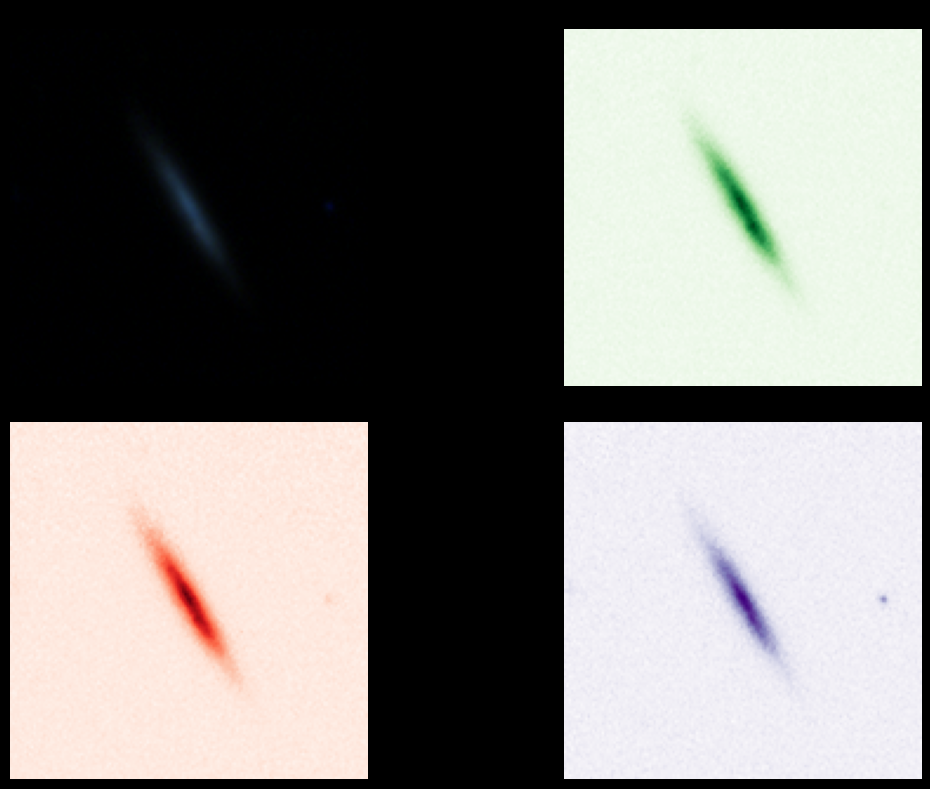

Type 'next', 'y', 'n', or 'stop':  stop


Stopping. Saving results...
Saved 195 records to correct_irregular_images.fits.
Saved 14 records to incorrect_irregular_images.fits.


In [70]:
# Display the first image
if shuffled_indexes:
    while True:
        current_index = shuffled_indexes.pop()
        current_id = sample_irregular[current_index]['SGA_ID']
        
        if current_id not in inspected_ids:
            inspected_ids.add(current_id)
        break
    update_display()
            
while running:
    user_input = input("Type 'next', 'y', 'n', or 'stop': ").strip().lower()
    handle_input(user_input)

In [71]:
Correct = Table.read('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/correct_irregular_images.fits')
Correct

SGA_ID,RA,DEC,G_MAG_SB26,Z_MAG_SB26,R_MAG_SB26,Morphology,Path,T_TYPE,Main_Type
int64,float64,float64,float32,float32,float32,bytes4,bytes76,float64,int64
914426,144.0254798891444,10.396799691409552,17.062056,16.24877,16.517584,Sm,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/144/SGA2020-914426.fits,9.0,-5
882143,189.2339852399536,0.6907795333077043,17.375595,16.842703,17.027681,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/189/SGA2020-882143.fits,10.0,-5
161970,90.02275487912158,-33.91814270939747,14.992814,14.075236,14.411466,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/090/SGA2020-161970.fits,10.0,-5
1101407,157.925282644611,12.282207357732819,17.717012,16.962757,17.247185,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/157/SGA2020-1101407.fits,10.0,-5
463302,124.05645271605165,49.54032626233609,16.92599,16.300571,16.44716,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/124/SGA2020-463302.fits,10.0,-5
183699,217.70268839589963,7.157158754077751,17.76546,17.231739,17.434856,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/217/SGA2020-183699.fits,10.0,-5
676711,346.33200743966864,16.866728989283164,14.7993,13.698194,14.156562,Sm,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/346/SGA2020-676711.fits,9.0,-5
568939,179.89805541955147,-2.1916626203547898,17.224173,16.37255,16.732853,Sm,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/179/SGA2020-568939.fits,9.0,-5
310441,154.67968459216263,46.04540463665452,15.897378,16.020426,15.534364,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/154/SGA2020-310441.fits,10.0,-5


In [72]:
Incorrect = Table.read('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/incorrect_irregular_images.fits')
Incorrect

SGA_ID,RA,DEC,G_MAG_SB26,Z_MAG_SB26,R_MAG_SB26,Morphology,Path,T_TYPE,Main_Type
int64,float64,float64,float32,float32,float32,bytes4,bytes76,float64,int64
321875,215.62794655085352,-1.2293205359176413,17.044615,16.299479,16.581024,Sm,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/215/SGA2020-321875.fits,9.0,-5
593966,126.91197800294185,-1.5338727724793157,17.044735,15.58093,16.222054,Sm,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/126/SGA2020-593966.fits,9.0,-5
1235231,61.17173366603598,-34.96540841442404,16.315697,15.76644,15.949975,Sm,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/061/SGA2020-1235231.fits,9.0,-5
744000,131.61458342636973,54.33524515670471,16.939125,15.565165,16.092808,Sm,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/131/SGA2020-744000.fits,9.0,-5
532961,23.150623878868895,17.756779294982405,15.711323,14.477995,15.011427,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/023/SGA2020-532961.fits,10.0,-5
982493,65.71547397072597,-56.227329936709246,16.273787,15.7768,15.955104,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/065/SGA2020-982493.fits,10.0,-5
1109259,158.54239047656375,58.06369179328184,16.557552,17.005808,16.62005,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/158/SGA2020-1109259.fits,10.0,-5
1043657,68.8714449017826,-39.516017853862266,15.543159,14.014356,14.643872,I,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/068/SGA2020-1043657.fits,10.0,-5
129382,167.5546838560949,-0.5735516142020093,17.496058,15.7971325,16.549088,Sm,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/167/SGA2020-129382.fits,9.0,-5


In [6]:
# Read the FITS files into Astropy tables
table_elliptical = Table.read('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/correct_elliptical_images.fits')
table_lenticular = Table.read('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/correct_lenticular_images.fits')
table_spiral = Table.read('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/correct_spiral_images.fits')
table_irregular = Table.read('/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/correct_irregular_images.fits')

print(f'Correct Elliptical: {len(table_elliptical)}')
print(f'Correct Lenticualr: {len(table_lenticular)}')
print(f'Correct Spiral: {len(table_spiral)}')
print(f'Correct Irregular: {len(table_irregular)}')
      
# Stack the tables vertically
total_correct = vstack([table_elliptical, table_lenticular, table_spirals, table_irregular])
total_correct

# Optionally, write the merged table to a new FITS file
#total_correct.write('total_correct.fits', overwrite=True)

Correct Elliptical: 1063
Correct Lenticualr: 1065
Correct Spiral: 1049
Correct Irregular: 1494


SGA_ID,RA,DEC,G_MAG_SB26,Z_MAG_SB26,R_MAG_SB26,Morphology,Path,T_TYPE,Main_Type
int64,float64,float64,float32,float32,float32,bytes4,bytes76,float64,int64
482869,190.1208575852055,44.65433728608076,17.013992,15.61396,16.086739,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/190/SGA2020-482869.fits,-5.0,20
728691,245.86260564206617,9.030334764566568,16.78021,15.257396,15.928763,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/245/SGA2020-728691.fits,-5.0,20
923378,225.8694580979221,7.09888557560782,16.20027,14.602061,15.258049,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/225/SGA2020-923378.fits,-5.0,20
735965,162.7432853236749,25.228010831434425,14.633182,13.153469,13.781071,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/162/SGA2020-735965.fits,-5.0,20
1104627,207.05301581248395,45.94059171704024,16.726818,15.328302,15.821358,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/207/SGA2020-1104627.fits,-5.0,20
487710,159.33445006826176,6.225200109690522,16.92429,15.371734,16.036863,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/159/SGA2020-487710.fits,-5.0,20
664714,123.46825581888227,41.938085711510524,16.875826,15.496156,15.9363785,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/123/SGA2020-664714.fits,-5.0,20
282391,172.2066248194935,43.156935743917174,16.233627,14.658493,15.300118,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/172/SGA2020-282391.fits,-5.0,20
204759,121.9882791050105,34.22733910022179,-1.0,-1.0,-1.0,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/121/SGA2020-204759.fits,-5.0,20


In [20]:
# Read the FITS file
file_path = '/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/total_correct.fits'
file_path = '/pscratch/sd/j/jlargett/DESI_SGA_MINE/Sorter/curated_training/VI_4000_sga152x152.fits'
table = Table.read(file_path)

# Extract the SGA_ID column
sga_ids = table['SGA_ID']

# Find unique SGA_IDs and their counts
unique_ids, counts = np.unique(sga_ids, return_counts=True)

# Identify duplicate SGA_IDs and their counts
duplicate_counts = {id_: count for id_, count in zip(unique_ids, counts) if count > 1}

# Identify duplicate SGA_IDs
duplicates = unique_ids[counts > 1]

if len(duplicate_counts) > 0:
    total_duplicates = sum(count - 1 for count in duplicate_counts.values())
    print(f"Total number of duplicate counts: {total_duplicates}")
    print(f"Found {len(duplicate_counts)} duplicate SGA_ID(s).")
    # Print the duplicated IDs with their counts
    for sga_id, count in duplicate_counts.items():
        print(f"SGA_ID: {sga_id}, Count: {count}")
else:
    print("No duplicate SGA_IDs found.")

No duplicate SGA_IDs found.


In [8]:
# Create a mask to keep only one occurrence of each duplicated SGA_ID
keep_mask = np.zeros(len(sga_ids), dtype=bool)
for duplicate_id in duplicates:
    # Find all indices of the current duplicate ID
    duplicate_indices = np.where(sga_ids == duplicate_id)[0]
    # Keep only the first occurrence of this duplicate ID
    keep_mask[duplicate_indices[0]] = True

# Add mask to keep non-duplicate IDs
non_duplicate_mask = np.isin(sga_ids, duplicates, invert=True)
final_mask = keep_mask | non_duplicate_mask

# Filter the table based on the final mask
filtered_table = table[final_mask]

# Save the filtered table to a new FITS file
filtered_file_path = 'total_correct_filtered.fits'
filtered_table.write(filtered_file_path, overwrite=True)

print(f"Removed extra duplicates. Filtered file saved as {filtered_file_path}.")

Removed extra duplicates. Filtered file saved as total_correct_filtered.fits.


In [10]:
filtered_table

SGA_ID,RA,DEC,G_MAG_SB26,Z_MAG_SB26,R_MAG_SB26,Morphology,Path,T_TYPE,Main_Type
int64,float64,float64,float32,float32,float32,bytes4,bytes76,float64,int64
482869,190.1208575852055,44.65433728608076,17.013992,15.61396,16.086739,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/190/SGA2020-482869.fits,-5.0,20
728691,245.86260564206617,9.030334764566568,16.78021,15.257396,15.928763,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/245/SGA2020-728691.fits,-5.0,20
923378,225.8694580979221,7.09888557560782,16.20027,14.602061,15.258049,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/225/SGA2020-923378.fits,-5.0,20
735965,162.7432853236749,25.228010831434425,14.633182,13.153469,13.781071,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/162/SGA2020-735965.fits,-5.0,20
1104627,207.05301581248395,45.94059171704024,16.726818,15.328302,15.821358,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/207/SGA2020-1104627.fits,-5.0,20
487710,159.33445006826176,6.225200109690522,16.92429,15.371734,16.036863,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/159/SGA2020-487710.fits,-5.0,20
664714,123.46825581888227,41.938085711510524,16.875826,15.496156,15.9363785,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/123/SGA2020-664714.fits,-5.0,20
282391,172.2066248194935,43.156935743917174,16.233627,14.658493,15.300118,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/172/SGA2020-282391.fits,-5.0,20
204759,121.9882791050105,34.22733910022179,-1.0,-1.0,-1.0,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/121/SGA2020-204759.fits,-5.0,20


In [15]:
unique_types, counts = np.unique(table['Main_Type'], return_counts=True)
for main_type, count in zip(unique_types, counts):
    print(f'Main_Type {int(main_type)}: {count}')

Main_Type -5: 1494
Main_Type 0: 1065
Main_Type 10: 1049
Main_Type 20: 1063


In [16]:
unique_types, counts = np.unique(filtered_table['Main_Type'], return_counts=True)
for main_type, count in zip(unique_types, counts):
    print(f'Main_Type {int(main_type)}: {count}')

Main_Type -5: 1017
Main_Type 0: 1030
Main_Type 10: 1038
Main_Type 20: 1053


In [17]:
# Define the number of samples you want from each Main_Type
n_samples = 1000

# Separate the table by Main_Type
type_20 = filtered_table[filtered_table['Main_Type'] == 20]
type_10 = filtered_table[filtered_table['Main_Type'] == 10]
type_0 = filtered_table[filtered_table['Main_Type'] == 0]
type_neg5 = filtered_table[filtered_table['Main_Type'] == -5]

# Randomly sample 1000 rows from each type (replace=False ensures no duplicates)
sampled_20 = type_20[np.random.choice(len(type_20), n_samples, replace=False)]
sampled_10 = type_10[np.random.choice(len(type_10), n_samples, replace=False)]
sampled_0 = type_0[np.random.choice(len(type_0), n_samples, replace=False)]
sampled_neg5 = type_neg5[np.random.choice(len(type_neg5), n_samples, replace=False)]

# Combine the sampled rows back into a single table
new_table = vstack([sampled_20, sampled_10, sampled_0, sampled_neg5])

# Save the new table to a file
new_table.write('VI_4000_sga152x152.fits', overwrite=True)

print('New table with 1000 rows of each Main_Type saved.')

New table with 1000 rows of each Main_Type saved.


In [18]:
new_table

SGA_ID,RA,DEC,G_MAG_SB26,Z_MAG_SB26,R_MAG_SB26,Morphology,Path,T_TYPE,Main_Type
int64,float64,float64,float32,float32,float32,bytes4,bytes76,float64,int64
831151,213.50590133336513,31.14820277680165,17.112806,15.652968,16.261892,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/213/SGA2020-831151.fits,-5.0,20
841964,182.22624176312948,60.71909972151271,16.788475,15.38398,15.91633,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/182/SGA2020-841964.fits,-5.0,20
742784,144.67146870358894,51.82606783519872,15.109658,13.753175,14.197537,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/144/SGA2020-742784.fits,-5.0,20
1007845,183.18355501719242,31.45016405607238,16.120312,14.581675,15.226092,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/183/SGA2020-1007845.fits,-5.0,20
396832,200.3449984394637,4.316768068365768,17.439743,15.729994,16.446762,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/200/SGA2020-396832.fits,-5.0,20
390387,260.13342956053185,28.100807627116676,16.428516,14.9278345,15.554991,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/260/SGA2020-390387.fits,-5.0,20
1005162,172.20077047896189,39.58459111102822,17.856558,15.999874,16.569624,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/172/SGA2020-1005162.fits,-5.0,20
1114887,257.3376728569469,34.385891584617156,16.198465,14.789537,15.240975,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/257/SGA2020-1114887.fits,-5.0,20
218605,236.44655492342625,33.7305541769225,16.447487,14.988185,15.537429,E,/pscratch/sd/i/ioannis/SGA2024-data/SGA2020-cutouts/236/SGA2020-218605.fits,-5.0,20


In [19]:
unique_types, counts = np.unique(new_table['Main_Type'], return_counts=True)
for main_type, count in zip(unique_types, counts):
    print(f'Main_Type {int(main_type)}: {count}')

Main_Type -5: 1000
Main_Type 0: 1000
Main_Type 10: 1000
Main_Type 20: 1000


In [5]:
# Copying result into my repository
test=Table.read('/global/homes/q/qshimp/morphology_classification/Generating_VI_Set/VI_4000_sga152x152.fits')
#test.write('/pscratch/sd/q/qshimp/SGA2020-data/Anchors/VI_4000_sga152x152.fits')